# Artifact detection for a FIF EEG recording

This notebook detects suspicious 4-second EEG epochs using hard signal-failure checks and robust within-recording outlier scores. By default, analysis is limited to the first 10,000 complete epochs. It flags epochs; it does not modify or interpolate the EEG. Review the diagnostic plots before using the mask for spectral analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

mne.set_log_level("WARNING")
pd.set_option("display.max_columns", 40)

## 1. Select and load the recording

Change `FIF_PATH` to the recording to analyze. EEG and EMG channels are selected from the channel types stored in the FIF file. EMG checks are optional and are skipped when no channel is typed as EMG.

In [2]:
FIF_PATH = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif")
EPOCH_SECONDS = 4.0
MAX_EPOCHS = 10_000
CHUNK_EPOCHS = 512

if not FIF_PATH.is_file():
    raise FileNotFoundError(f"Set FIF_PATH to an existing .fif file: {FIF_PATH}")

raw = mne.io.read_raw_fif(FIF_PATH, preload=False, verbose="ERROR")
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude=[])
if len(eeg_picks) == 0:
    raise ValueError("No channels typed as EEG were found in the FIF file.")
eeg = raw.copy().pick(eeg_picks)
emg_picks = mne.pick_types(raw.info, emg=True, exclude=[])
emg = raw.copy().pick(emg_picks) if len(emg_picks) else None

sfreq = float(eeg.info["sfreq"])
epoch_samples = int(round(EPOCH_SECONDS * sfreq))
total_complete_epochs = eeg.n_times // epoch_samples
n_epochs = min(total_complete_epochs, MAX_EPOCHS)
duration_h = eeg.n_times / sfreq / 3600

print(f"Loaded: {FIF_PATH}")
print(f"EEG channels: {eeg.ch_names}")
print(f"EMG channels: {emg.ch_names if emg is not None else 'none (EMG checks disabled)'}")
print(f"Sampling rate: {sfreq:g} Hz | duration: {duration_h:.2f} h")
print(f"Complete {EPOCH_SECONDS:g}-s epochs in recording: {total_complete_epochs:,}")
print(f"Epochs selected for artifact detection: {n_epochs:,} (first {n_epochs * EPOCH_SECONDS / 3600:.2f} h)")

Loaded: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif
EEG channels: ['EEG1A-B', 'EEG2A-B']
EMG channels: ['EMG']
Sampling rate: 128 Hz | duration: 71.18 h
Complete 4-s epochs in recording: 64,060
Epochs selected for artifact detection: 10,000 (first 11.11 h)


## 2. Load and align sleep-scored states

Set `PARQUET_PATH` to the sleep-scoring file for the same recording. The default columns match the project's scoring output: `time_s` is time from recording start and `label` is the sleep state. Scores are assigned to 4-second epochs using the most frequent state within each epoch.

In [3]:
PARQUET_PATH = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet")
SLEEP_TIME_COLUMN = "time_s"
SLEEP_STATE_COLUMN = "label"

if not PARQUET_PATH.is_file():
    raise FileNotFoundError(f"Set PARQUET_PATH to the matching sleep-scoring parquet file: {PARQUET_PATH}")

sleep_df = pd.read_parquet(PARQUET_PATH)
required_columns = {SLEEP_TIME_COLUMN, SLEEP_STATE_COLUMN}
missing_columns = required_columns.difference(sleep_df.columns)
if missing_columns:
    raise ValueError(f"Sleep-scoring parquet is missing columns: {sorted(missing_columns)}")

scores = sleep_df[[SLEEP_TIME_COLUMN, SLEEP_STATE_COLUMN]].dropna().copy()
scores = scores.loc[
    (scores[SLEEP_TIME_COLUMN] >= 0)
    & (scores[SLEEP_TIME_COLUMN] < n_epochs * EPOCH_SECONDS)
].copy()
scores["epoch_id"] = np.floor(scores[SLEEP_TIME_COLUMN] / EPOCH_SECONDS).astype("int64")

def majority_state(values):
    modes = values.mode()
    return modes.iloc[0] if not modes.empty else np.nan

epoch_sleep_df = scores.groupby("epoch_id", as_index=False).agg(
    sleep_state=(SLEEP_STATE_COLUMN, majority_state),
    sleep_score_count=(SLEEP_STATE_COLUMN, "size"),
)
all_selected_epochs = pd.DataFrame({"epoch_id": np.arange(n_epochs, dtype=np.int64)})
epoch_sleep_df = all_selected_epochs.merge(epoch_sleep_df, on="epoch_id", how="left")
if pd.api.types.is_numeric_dtype(scores[SLEEP_STATE_COLUMN]):
    UNSCORED_STATE = -1
    epoch_sleep_df["sleep_state"] = pd.to_numeric(epoch_sleep_df["sleep_state"]).fillna(UNSCORED_STATE)
else:
    UNSCORED_STATE = "unscored"
    epoch_sleep_df["sleep_state"] = epoch_sleep_df["sleep_state"].astype("string").fillna(UNSCORED_STATE)
epoch_sleep_df["sleep_score_count"] = epoch_sleep_df["sleep_score_count"].fillna(0).astype(int)

print(f"Loaded sleep scores: {PARQUET_PATH}")
print(f"Selected epochs without a score: {(epoch_sleep_df['sleep_state'] == UNSCORED_STATE).sum():,}")
display(epoch_sleep_df["sleep_state"].value_counts(dropna=False).rename_axis("sleep_state").to_frame("epochs"))

Loaded sleep scores: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet
Selected epochs without a score: 0


,epochs
sleep_state,
0,5544
1,3881
2,573
3,2


## 3. Extract artifact-sensitive features

Features are calculated per epoch and EEG channel. Amplitudes are converted from volts to microvolts. High-frequency power is useful for movement/muscle contamination; line-noise power is calculated around 50 Hz when the sampling rate supports it. EMG peak-to-peak amplitude, RMS, and maximum derivative are calculated for every available EMG channel.

In [4]:
def bandpower(psd, frequencies, low, high):
    mask = (frequencies >= low) & (frequencies <= high)
    if mask.sum() < 2:
        return np.full(psd.shape[:-1], np.nan)
    return np.trapezoid(psd[..., mask], frequencies[mask], axis=-1)


nyquist = sfreq / 2
psd_fmax = min(55.0, nyquist - sfreq / epoch_samples)
n_per_seg = min(epoch_samples, int(round(2 * sfreq)))
n_fft = 1 << (n_per_seg - 1).bit_length()
n_overlap = n_per_seg // 2
rows = []
emg_rows = []

for first_epoch in range(0, n_epochs, CHUNK_EPOCHS):
    last_epoch = min(first_epoch + CHUNK_EPOCHS, n_epochs)
    samples = eeg.get_data(
        start=first_epoch * epoch_samples,
        stop=last_epoch * epoch_samples,
    )
    batch = samples.reshape(len(eeg.ch_names), last_epoch - first_epoch, epoch_samples)
    batch = np.moveaxis(batch, 1, 0) * 1e6  # epochs x channels x samples, µV
    nonfinite = ~np.isfinite(batch).all(axis=-1)
    clean_for_features = np.nan_to_num(batch, nan=0.0, posinf=0.0, neginf=0.0)

    peak_to_peak = np.ptp(clean_for_features, axis=-1)
    rms = np.sqrt(np.mean(clean_for_features**2, axis=-1))
    max_derivative = np.max(np.abs(np.diff(clean_for_features, axis=-1)), axis=-1)
    standard_deviation = np.std(clean_for_features, axis=-1)
    epoch_min = clean_for_features.min(axis=-1, keepdims=True)
    epoch_max = clean_for_features.max(axis=-1, keepdims=True)
    edge_fraction = np.maximum(
        np.mean(clean_for_features == epoch_min, axis=-1),
        np.mean(clean_for_features == epoch_max, axis=-1),
    )

    psd, frequencies = mne.time_frequency.psd_array_welch(
        clean_for_features, sfreq=sfreq, fmin=1.0, fmax=psd_fmax,
        n_fft=n_fft, n_per_seg=n_per_seg, n_overlap=n_overlap, verbose=False,
    )
    high_frequency_power = bandpower(psd, frequencies, 20.0, min(45.0, psd_fmax))
    line_noise_power = bandpower(psd, frequencies, 49.0, min(51.0, psd_fmax))

    if emg is not None:
        emg_samples = emg.get_data(
            start=first_epoch * epoch_samples,
            stop=last_epoch * epoch_samples,
        )
        emg_batch = emg_samples.reshape(len(emg.ch_names), last_epoch - first_epoch, epoch_samples)
        emg_batch = np.moveaxis(emg_batch, 1, 0) * 1e6
        emg_nonfinite = ~np.isfinite(emg_batch).all(axis=-1)
        emg_clean = np.nan_to_num(emg_batch, nan=0.0, posinf=0.0, neginf=0.0)
        emg_peak_to_peak = np.ptp(emg_clean, axis=-1)
        emg_rms = np.sqrt(np.mean(emg_clean**2, axis=-1))
        emg_max_derivative = np.max(np.abs(np.diff(emg_clean, axis=-1)), axis=-1)

    for offset in range(last_epoch - first_epoch):
        epoch_id = first_epoch + offset
        for channel_index, channel in enumerate(eeg.ch_names):
            rows.append({
                "epoch_id": epoch_id,
                "time_s": epoch_id * EPOCH_SECONDS,
                "time_h": epoch_id * EPOCH_SECONDS / 3600,
                "channel": channel,
                "peak_to_peak_uv": peak_to_peak[offset, channel_index],
                "rms_uv": rms[offset, channel_index],
                "max_derivative_uv_per_sample": max_derivative[offset, channel_index],
                "std_uv": standard_deviation[offset, channel_index],
                "edge_fraction": edge_fraction[offset, channel_index],
                "high_frequency_power_uv2": high_frequency_power[offset, channel_index],
                "line_noise_power_uv2": line_noise_power[offset, channel_index],
                "nonfinite": nonfinite[offset, channel_index],
            })
        if emg is not None:
            for channel_index, channel in enumerate(emg.ch_names):
                emg_rows.append({
                    "epoch_id": epoch_id,
                    "emg_channel": channel,
                    "emg_peak_to_peak_uv": emg_peak_to_peak[offset, channel_index],
                    "emg_rms_uv": emg_rms[offset, channel_index],
                    "emg_max_derivative_uv_per_sample": emg_max_derivative[offset, channel_index],
                    "emg_nonfinite": emg_nonfinite[offset, channel_index],
                })

features_df = pd.DataFrame(rows)
emg_features_df = pd.DataFrame(emg_rows)
features_df = features_df.merge(epoch_sleep_df, on="epoch_id", how="left", validate="many_to_one")
if not emg_features_df.empty:
    emg_features_df = emg_features_df.merge(epoch_sleep_df, on="epoch_id", how="left", validate="many_to_one")
print(f"Created {len(features_df):,} epoch-channel feature rows")
print(f"Created {len(emg_features_df):,} EMG epoch-channel feature rows")
features_df.head()

Created 20,000 epoch-channel feature rows
Created 10,000 EMG epoch-channel feature rows


,epoch_id,time_s,time_h,channel,peak_to_peak_uv,rms_uv,max_derivative_uv_per_sample,std_uv,edge_fraction,high_frequency_power_uv2,line_noise_power_uv2,nonfinite,sleep_state,sleep_score_count
0,0,0.0,0.000000,EEG1A-B,288.726049,51.252336,159.661053,49.709104,0.001953,422.219704,18.203037,False,0,4
1,0,0.0,0.000000,EEG2A-B,173.072847,34.415222,123.891343,26.527572,0.001953,202.471012,16.284386,False,0,4
2,1,4.0,0.001111,EEG1A-B,253.004953,48.195923,161.422824,46.837954,0.001953,363.025775,13.537012,False,0,4
3,1,4.0,0.001111,EEG2A-B,145.487902,36.096855,86.490114,25.508490,0.001953,168.510294,10.951858,False,0,4
4,2,8.0,0.002222,EEG1A-B,306.300863,50.782171,169.493382,48.808060,0.001953,654.427017,45.781324,False,0,4


## 4. Apply state-dependent robust artifact rules

The median and median absolute deviation (MAD) are estimated separately for every EEG and EMG channel. Positive features are log-transformed before scoring. EEG-only rules flag hard failures, two moderately extreme features, or one exceptionally extreme feature. An EMG outlier supports rejection only when at least one EEG feature is also abnormal, reducing false rejection of physiological high EMG during wake. Adjust these starting thresholds after visually reviewing examples from your own recordings.

In [5]:
ROBUST_Z_THRESHOLD = 5.0
EXTREME_Z_THRESHOLD = 8.0
MIN_STD_UV = 0.1
MAX_EDGE_FRACTION = 0.02

score_features = [
    "peak_to_peak_uv",
    "rms_uv",
    "max_derivative_uv_per_sample",
    "high_frequency_power_uv2",
    "line_noise_power_uv2",
]

def robust_upper_z(values):
    values = np.asarray(values, dtype=float)
    transformed = np.log10(np.clip(values, np.finfo(float).tiny, None))
    finite = np.isfinite(transformed)
    result = np.full(transformed.shape, np.nan)
    if not finite.any():
        return result
    median = np.median(transformed[finite])
    mad = np.median(np.abs(transformed[finite] - median))
    if mad == 0:
        result[finite] = 0.0
    else:
        result[finite] = (transformed[finite] - median) / (1.4826 * mad)
    return result

emg_score_features = [
    "emg_peak_to_peak_uv",
    "emg_rms_uv",
    "emg_max_derivative_uv_per_sample",
]
if not emg_features_df.empty:
    for feature in emg_score_features:
        emg_features_df[f"z_{feature}"] = emg_features_df.groupby(["emg_channel", "sleep_state"])[feature].transform(robust_upper_z)
    emg_z_columns = [f"z_{feature}" for feature in emg_score_features]
    emg_features_df["emg_soft_feature_count"] = (emg_features_df[emg_z_columns] > ROBUST_Z_THRESHOLD).sum(axis=1)
    emg_features_df["emg_max_robust_z"] = emg_features_df[emg_z_columns].max(axis=1, skipna=True)
    emg_features_df["emg_extreme"] = (
        emg_features_df["emg_nonfinite"]
        | (emg_features_df["emg_soft_feature_count"] >= 2)
        | (emg_features_df["emg_max_robust_z"] > EXTREME_Z_THRESHOLD)
    )
    epoch_emg_df = emg_features_df.groupby("epoch_id", as_index=False).agg(
        emg_extreme=("emg_extreme", "any"),
        emg_rms_uv=("emg_rms_uv", "max"),
        emg_peak_to_peak_uv=("emg_peak_to_peak_uv", "max"),
        emg_max_robust_z=("emg_max_robust_z", "max"),
    )
else:
    epoch_emg_df = pd.DataFrame({
        "epoch_id": np.arange(n_epochs),
        "emg_extreme": False,
        "emg_rms_uv": np.nan,
        "emg_peak_to_peak_uv": np.nan,
        "emg_max_robust_z": np.nan,
    })

for feature in score_features:
    features_df[f"z_{feature}"] = features_df.groupby(["channel", "sleep_state"])[feature].transform(robust_upper_z)

z_columns = [f"z_{feature}" for feature in score_features]
features_df["soft_feature_count"] = (features_df[z_columns] > ROBUST_Z_THRESHOLD).sum(axis=1)
features_df["max_robust_z"] = features_df[z_columns].max(axis=1, skipna=True)
features_df["hard_failure"] = (
    features_df["nonfinite"]
    | (features_df["std_uv"] < MIN_STD_UV)
    | (features_df["edge_fraction"] > MAX_EDGE_FRACTION)
)
features_df = features_df.merge(epoch_emg_df, on="epoch_id", how="left", validate="many_to_one")
features_df["emg_supported_artifact"] = (
    features_df["emg_extreme"]
    & (features_df["soft_feature_count"] >= 1)
)
features_df["artifact"] = (
    features_df["hard_failure"]
    | (features_df["soft_feature_count"] >= 2)
    | (features_df["max_robust_z"] > EXTREME_Z_THRESHOLD)
    | features_df["emg_supported_artifact"]
)

def artifact_reason(row):
    reasons = []
    if row["nonfinite"]: reasons.append("nonfinite")
    if row["std_uv"] < MIN_STD_UV: reasons.append("flatline")
    if row["edge_fraction"] > MAX_EDGE_FRACTION: reasons.append("clipping_or_repeated_edge")
    if row["emg_supported_artifact"]: reasons.append("emg_outlier_with_eeg_outlier")
    reasons.extend(feature for feature in score_features if row[f"z_{feature}"] > ROBUST_Z_THRESHOLD)
    return ";".join(reasons)

features_df["artifact_reason"] = features_df.apply(artifact_reason, axis=1)
artifact_epoch_df = features_df.groupby("epoch_id", as_index=False).agg(
    time_s=("time_s", "first"),
    time_h=("time_h", "first"),
    sleep_state=("sleep_state", "first"),
    artifact=("artifact", "any"),
    affected_channels=("artifact", "sum"),
    max_robust_z=("max_robust_z", "max"),
    emg_extreme=("emg_extreme", "first"),
    emg_rms_uv=("emg_rms_uv", "first"),
    emg_max_robust_z=("emg_max_robust_z", "first"),
)
artifact_reason_df = features_df.loc[
    features_df["artifact"] & features_df["artifact_reason"].ne(""),
    ["epoch_id", "channel", "artifact_reason"],
].copy()
artifact_reason_df["channel_reason"] = (
    artifact_reason_df["channel"].astype(str)
    + ":"
    + artifact_reason_df["artifact_reason"]
)
artifact_reason_df = artifact_reason_df.groupby("epoch_id", as_index=False).agg(
    artifact_features=("channel_reason", lambda values: " | ".join(dict.fromkeys(values)))
)
artifact_epoch_df = artifact_epoch_df.merge(artifact_reason_df, on="epoch_id", how="left")
artifact_epoch_df["artifact_features"] = artifact_epoch_df["artifact_features"].fillna("")

display(features_df.groupby(["channel", "sleep_state"])["artifact"].agg(["sum", "count", "mean"]))
if emg is not None:
    print(f"Epochs with extreme EMG features: {epoch_emg_df['emg_extreme'].sum():,} / {len(epoch_emg_df):,} ({epoch_emg_df['emg_extreme'].mean():.2%})")
print(f"Epochs flagged in any EEG channel: {artifact_epoch_df['artifact'].sum():,} / {len(artifact_epoch_df):,} ({artifact_epoch_df['artifact'].mean():.2%})")

sum  count      mean
channel sleep_state                      
EEG1A-B 0             97   5544  0.017496
        1             20   3881  0.005153
        2              1    573  0.001745
        3              0      2  0.000000
EEG2A-B 0            273   5544  0.049242
        1             25   3881  0.006442
        2              5    573  0.008726
        3              0      2  0.000000

Epochs with extreme EMG features: 35 / 10,000 (0.35%)
Epochs flagged in any EEG channel: 312 / 10,000 (3.12%)


## 5. Diagnostics

Scatter points are not joined. Red points are flagged epoch-channel pairs. Use the channel selector to inspect each EEG channel.

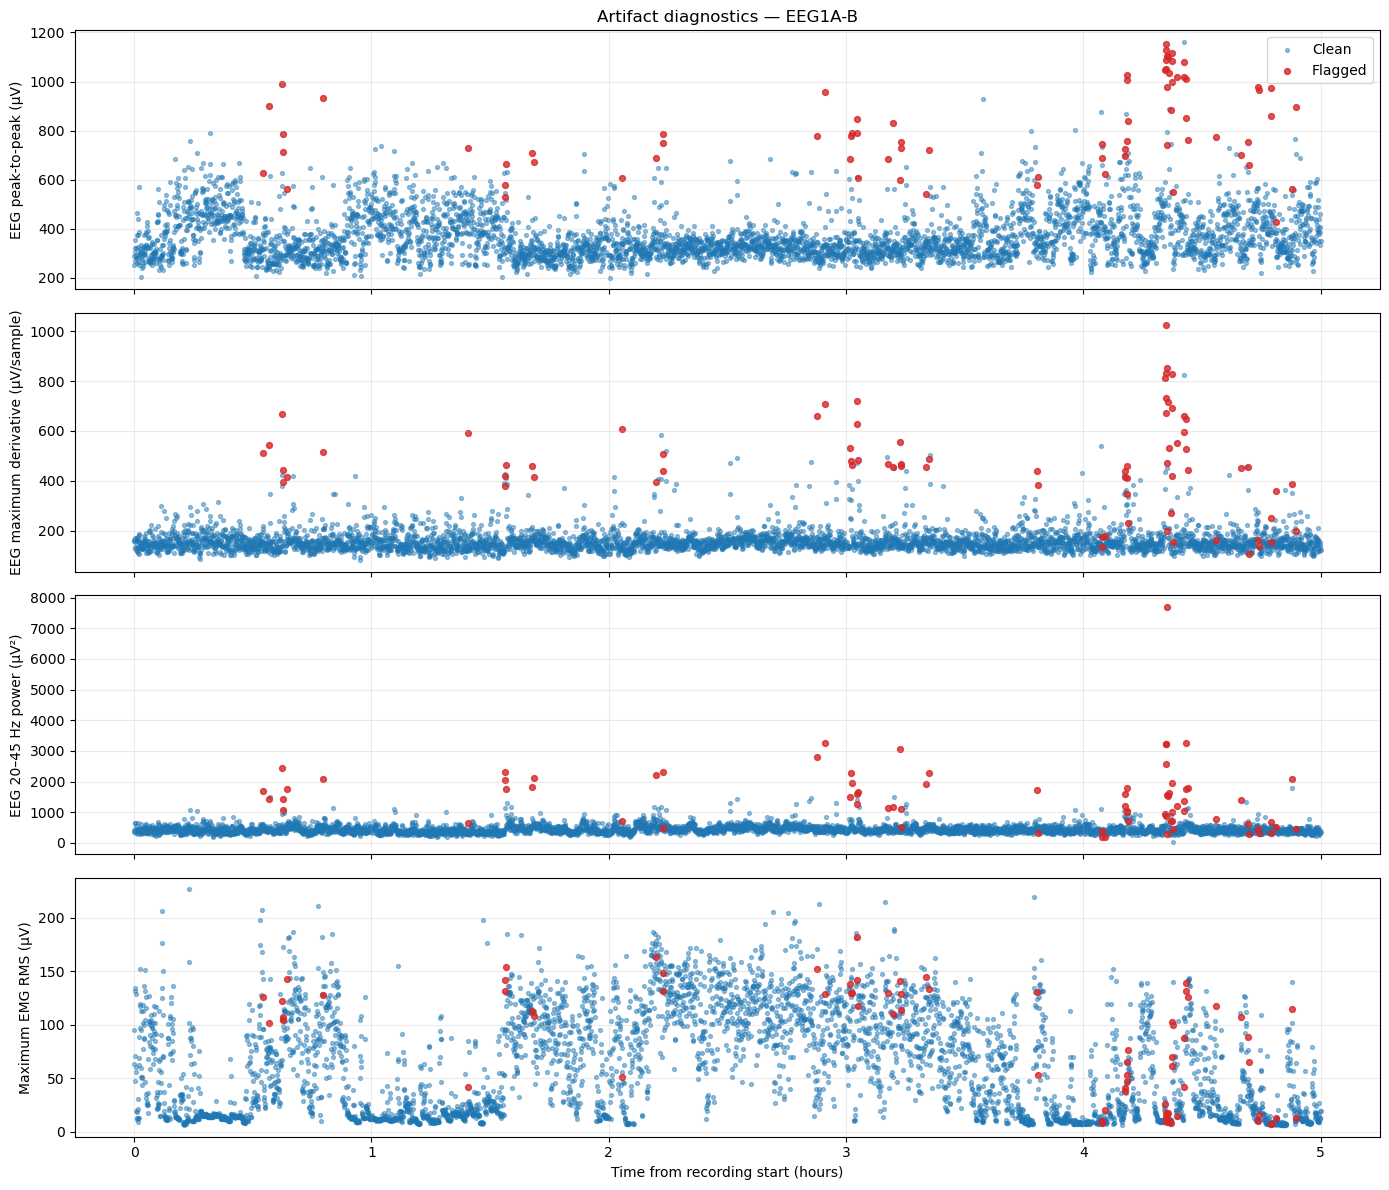

In [6]:
CHANNEL_TO_PLOT = eeg.ch_names[0]
MAX_HOURS_TO_PLOT = min(5.0, duration_h)

plot_df = features_df.loc[
    (features_df["channel"] == CHANNEL_TO_PLOT)
    & (features_df["time_h"] <= MAX_HOURS_TO_PLOT)
].copy()
clean = ~plot_df["artifact"]
flagged = plot_df["artifact"]

diagnostic_specs = [
    ("peak_to_peak_uv", "EEG peak-to-peak (µV)"),
    ("max_derivative_uv_per_sample", "EEG maximum derivative (µV/sample)"),
    ("high_frequency_power_uv2", "EEG 20–45 Hz power (µV²)"),
]
if emg is not None:
    diagnostic_specs.append(("emg_rms_uv", "Maximum EMG RMS (µV)"))
fig, axes = plt.subplots(len(diagnostic_specs), 1, figsize=(14, 3 * len(diagnostic_specs)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (feature, ylabel) in zip(axes, diagnostic_specs):
    ax.scatter(plot_df.loc[clean, "time_h"], plot_df.loc[clean, feature], s=8, alpha=0.45, color="tab:blue", label="Clean")
    ax.scatter(plot_df.loc[flagged, "time_h"], plot_df.loc[flagged, feature], s=18, alpha=0.8, color="tab:red", label="Flagged")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
axes[0].legend()
axes[0].set_title(f"Artifact diagnostics — {CHANNEL_TO_PLOT}")
axes[-1].set_xlabel("Time from recording start (hours)")
plt.tight_layout()
plt.show()

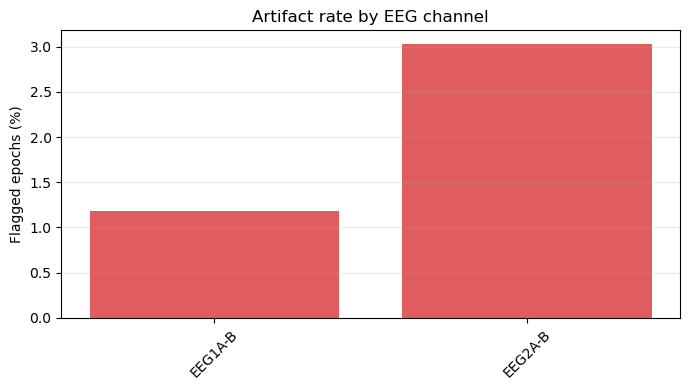

In [7]:
# Artifact percentage by EEG channel.
channel_summary = (100 * features_df.groupby("channel")["artifact"].mean()).sort_values()
fig, ax = plt.subplots(figsize=(max(7, len(channel_summary) * 0.8), 4))
ax.bar(channel_summary.index, channel_summary.values, color="tab:red", alpha=0.75)
ax.set_ylabel("Flagged epochs (%)")
ax.set_title("Artifact rate by EEG channel")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Inspect candidate epochs

The table below lists the most extreme flagged rows. Change `EPOCH_TO_INSPECT` in the following cell to inspect the surrounding raw EEG and any available EMG channels in a kernel-safe inline plot.

In [8]:
candidate_columns = [
    "epoch_id", "time_h", "sleep_state", "channel", "artifact_reason",
    "peak_to_peak_uv", "rms_uv", "max_derivative_uv_per_sample",
    "high_frequency_power_uv2", "line_noise_power_uv2", "max_robust_z",
    "emg_rms_uv", "emg_peak_to_peak_uv", "emg_max_robust_z", "emg_extreme",
]
features_df.loc[features_df["artifact"], candidate_columns].sort_values(
    "max_robust_z", ascending=False
).head(30)

,epoch_id,time_h,sleep_state,channel,artifact_reason,peak_to_peak_uv,rms_uv,max_derivative_uv_per_sample,high_frequency_power_uv2,line_noise_power_uv2,max_robust_z,emg_rms_uv,emg_peak_to_peak_uv,emg_max_robust_z,emg_extreme
7877,3938,4.375556,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1028.449798,332.794398,807.798817,1969.266312,28.930598,27.985182,103.081600,822.523551,0.526265,False
7875,3937,4.374444,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1072.738494,317.908668,752.132881,3269.010589,63.313209,27.400875,69.893931,450.494961,-0.409181,False
7533,3766,4.184444,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,986.357278,301.537655,359.931139,734.420183,18.924160,26.725801,53.534339,349.706737,-0.914065,False
7535,3767,4.185556,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1005.949860,292.488967,411.017161,1336.084487,52.053582,26.336763,65.380546,400.197328,-0.535573,False
19037,9518,10.575556,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,976.870186,240.854666,260.038192,222.851965,13.122530,23.856648,131.820755,774.643064,0.792110,False
7963,3981,4.423333,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1068.837009,216.188353,685.360792,1474.197374,61.288303,22.477066,87.602769,814.168277,0.726589,False
19409,9704,10.782222,0,EEG2A-B,peak_to_peak_uv;rms_uv,994.886155,210.061248,170.630985,250.345036,16.971855,22.109953,63.291108,553.021324,-0.489945,False
18839,9419,10.465556,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1012.620050,205.134371,823.506882,953.037750,19.284819,21.806901,112.146531,922.876963,1.148032,False
16505,8252,9.168889,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1091.560523,144.047505,650.882794,7875.810882,347.253881,20.962281,109.674517,669.437402,0.443866,False
18945,9472,10.524444,0,EEG2A-B,peak_to_peak_uv;rms_uv;max_derivative_uv_per_s...,1000.414486,120.584818,623.112865,6943.887160,225.655129,20.251443,127.056064,867.459865,0.722406,False


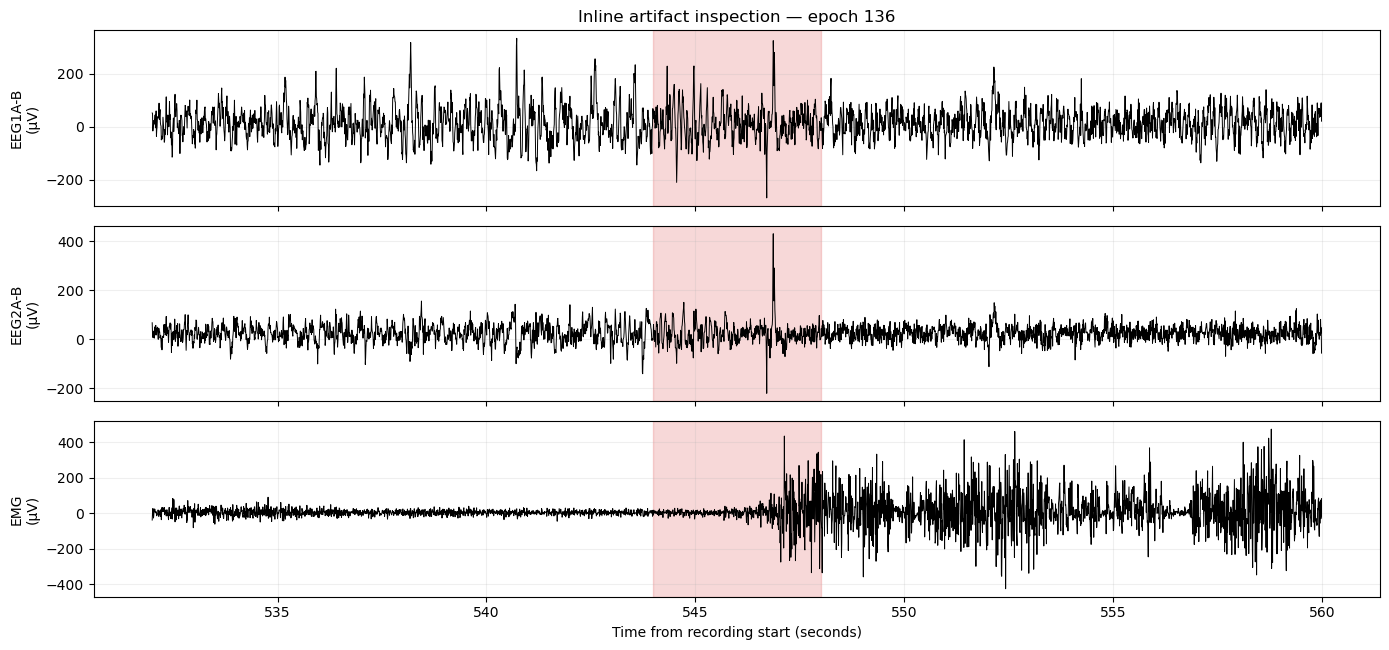

In [9]:
flagged_epoch_ids = artifact_epoch_df.loc[artifact_epoch_df["artifact"], "epoch_id"]
if flagged_epoch_ids.empty:
    raise ValueError("No artifact epochs are available to inspect.")
EPOCH_TO_INSPECT = int(flagged_epoch_ids.iloc[0])  # Change to another candidate epoch_id.
CONTEXT_SECONDS = 12
start_s = max(0.0, EPOCH_TO_INSPECT * EPOCH_SECONDS - CONTEXT_SECONDS)
stop_s = min(raw.times[-1], EPOCH_TO_INSPECT * EPOCH_SECONDS + EPOCH_SECONDS + CONTEXT_SECONDS)
inspection_picks = eeg.ch_names + (emg.ch_names if emg is not None else [])
inspection_data = raw.get_data(
    picks=inspection_picks,
    start=int(round(start_s * sfreq)),
    stop=int(round(stop_s * sfreq)),
) * 1e6
inspection_time = start_s + np.arange(inspection_data.shape[1]) / sfreq
epoch_start_s = EPOCH_TO_INSPECT * EPOCH_SECONDS
epoch_stop_s = epoch_start_s + EPOCH_SECONDS

fig, axes = plt.subplots(len(inspection_picks), 1, figsize=(14, 2.2 * len(inspection_picks)), sharex=True)
axes = np.atleast_1d(axes)
for ax, channel, signal in zip(axes, inspection_picks, inspection_data):
    ax.plot(inspection_time, signal, linewidth=0.7, color="black")
    ax.axvspan(epoch_start_s, epoch_stop_s, color="tab:red", alpha=0.18)
    ax.set_ylabel(f"{channel}\n(µV)")
    ax.grid(alpha=0.2)
axes[0].set_title(f"Inline artifact inspection — epoch {EPOCH_TO_INSPECT}")
axes[-1].set_xlabel("Time from recording start (seconds)")
plt.tight_layout()
plt.show()

## 7. Export results

Epoch-level artifact results are saved as CSV and Parquet files in the same directory as the sleep-scoring parquet. The `artifact_features` column records the channel and feature-based reasons responsible for each artifact decision.

In [10]:
OUTPUT_DIR = PARQUET_PATH.parent
output_stem = PARQUET_PATH.stem.replace("somnotate_predictions", "").rstrip("_-")
epoch_csv_path = OUTPUT_DIR / f"{output_stem}_artifact_epochs.csv"
epoch_parquet_path = OUTPUT_DIR / f"{output_stem}_artifact_epochs.parquet"

artifact_epoch_df.to_csv(epoch_csv_path, index=False)
artifact_epoch_df.to_parquet(epoch_parquet_path, index=False)

for saved_path in [epoch_csv_path, epoch_parquet_path]:
    print(f"Saved: {saved_path}")

Saved: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_artifact_epochs.csv
Saved: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_artifact_epochs.parquet
